# Error Statistics Analysis

Histogram of model error distribution for selected stations.

[REMOVE_BIAS=False] bias NON rimosso: +6.147 cm

═══════════════════════════════════════
Error Statistics — station_31616_Gedser
═══════════════════════════════════════
  N observations  : 60,637
  Mean            : +6.147 cm
  Median          : +5.668 cm
  Std             : 6.936 cm
  Skewness        : +0.123
  Kurtosis        : +2.359
  RMSE            : 9.268 cm
  MAE             : 7.319 cm
═══════════════════════════════════════


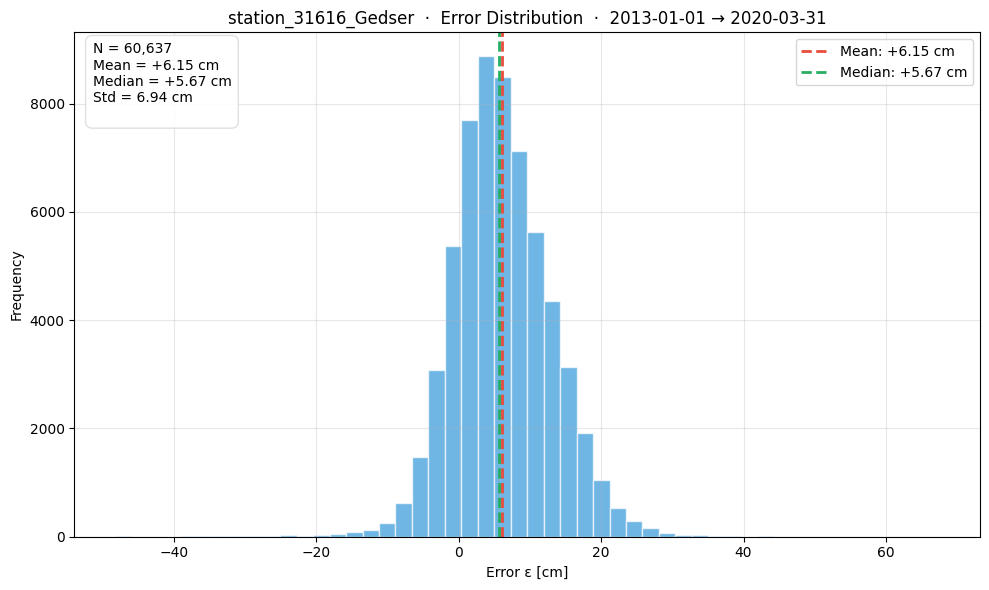

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# ════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS
# ════════════════════════════════════════════════════════════════════════
STATION_PATH = "/Users/nicolocaron/Desktop/MASTER PROJECT/data/per_station/station_31616_Gedser.parquet"
REMOVE_BIAS = False   # True  → sottrae la media temporale di (Model − TG)
                      # False → lascia l'errore invariato
# ════════════════════════════════════════════════════════════════════════

# ── Load data ──────────────────────────────────────────────────────────
df = pd.read_parquet(STATION_PATH)
df = df.sort_values("time").reset_index(drop=True)

station_label = STATION_PATH.split("/")[-1].replace(".parquet", "")
start_date = df["time"].min().strftime("%Y-%m-%d")
end_date = df["time"].max().strftime("%Y-%m-%d")

# ── Compute error ──────────────────────────────────────────────────────
df["error_m"] = df["forcoast_p82_m"] - df["tg_obs_m"]

# ── Bias correction ──────────────────────────────────────────────────────
mean_bias = df["error_m"].mean()
if REMOVE_BIAS:
    df["error_m"] -= mean_bias
    print(f"[REMOVE_BIAS=True]  bias rimosso: {mean_bias*100:+.3f} cm → ε centrata in 0")
else:
    print(f"[REMOVE_BIAS=False] bias NON rimosso: {mean_bias*100:+.3f} cm")

# ── Compute statistics ──────────────────────────────────────────────────
err = df["error_m"].dropna()
n = len(err)
mean_val = err.mean()
median_val = err.median()
std_val = err.std()
skew_val = skew(err)
kurt_val = kurtosis(err)  # excess kurtosis
rmse_val = np.sqrt((err**2).mean())
mae_val = err.abs().mean()

print(f"\n═══════════════════════════════════════")
print(f"Error Statistics — {station_label}")
print(f"═══════════════════════════════════════")
print(f"  N observations  : {n:,}")
print(f"  Mean            : {mean_val*100:+.3f} cm")
print(f"  Median          : {median_val*100:+.3f} cm")
print(f"  Std             : {std_val*100:.3f} cm")
print(f"  Skewness        : {skew_val:+.3f}")
print(f"  Kurtosis        : {kurt_val:+.3f}")
print(f"  RMSE            : {rmse_val*100:.3f} cm")
print(f"  MAE             : {mae_val*100:.3f} cm")
print(f"═══════════════════════════════════════")

# ── Histogram (no Gaussian fit) ────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(err * 100, bins=50, alpha=0.7, color="#3498DB",
        edgecolor="white", density=False)

# Vertical lines for mean and median
ax.axvline(mean_val * 100, color="#E74C3C", linestyle="--", linewidth=2,
           label=f"Mean: {mean_val*100:+.2f} cm")
ax.axvline(median_val * 100, color="#27AE60", linestyle="--", linewidth=2,
           label=f"Median: {median_val*100:+.2f} cm")

# Statistics text box (same info as dashboard annotation)
stats_text = (
    f"N = {n:,}\n"
    f"Mean = {mean_val*100:+.2f} cm\n"
    f"Median = {median_val*100:+.2f} cm\n"
    f"Std = {std_val*100:.2f} cm\n"
)
props = dict(boxstyle="round,pad=0.5", facecolor="white",
             edgecolor="#ddd", alpha=0.9)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment="top", bbox=props)

ax.set_xlabel("Error ε [cm]")
ax.set_ylabel("Frequency")
ax.set_title(f"{station_label}  ·  Error Distribution  ·  {start_date} → {end_date}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()